<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Learning-Curve-and-PR%2FROC-Curve/Learning_Curve_and_PR_ROC_Curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learning Curve and PR/ROC Curve

In [2]:
import matplotlib.pyplot as plt

def plot_learning_curves(model_class, X, y, **params):
    train_errors, val_errors = [], []
    # Test on different training set sizes
    m_sizes = np.linspace(0.1, 0.9, 10) * len(X)

    for m in m_sizes.astype(int):
        X_train, X_val, y_train, y_val = train_test_split(X[:m+50], y[:m+50], test_size=0.2)

        model = model_class(**params)
        model.fit(X_train, y_train)

        # Track Error (1 - Accuracy)
        train_errors.append(1 - np.mean(model.predict(X_train) == y_train))
        val_errors.append(1 - np.mean(model.predict(X_val) == y_val))

    plt.plot(m_sizes, train_errors, "r-+", linewidth=2, label="Train Error")
    plt.plot(m_sizes, val_errors, "b-", linewidth=3, label="Val Error")
    plt.title("Learning Curves: Is your model too simple or too complex?")
    plt.xlabel("Training Set Size")
    plt.ylabel("Error Rate")
    plt.legend()
    plt.show()

Scratch implementation of Learning Curve

In [3]:
import seaborn as sns

def plot_confusion_matrix(matrix, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix: Where are the misclassifications?")
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

Scratch implementation of Confusion Matrix

In [4]:
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_true, y_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='purple', label='PR Curve')
    plt.fill_between(recall, precision, alpha=0.2, color='purple')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Positive Predictive Value)')
    plt.title('Precision-Recall Curve: Handling Imbalanced Data')
    plt.legend()
    plt.show()

Scratch implementation of ROC Curve

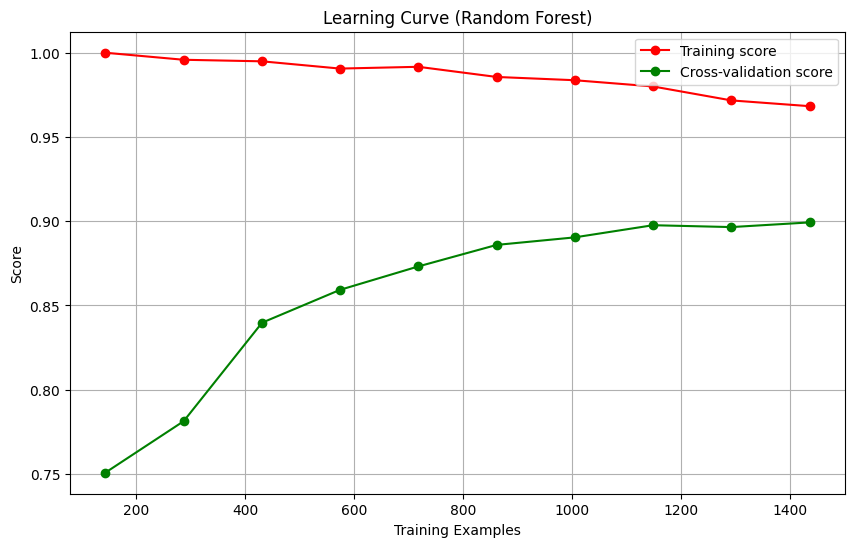

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits

def show_learning_curve():
    X, y = load_digits(return_X_y=True)
    model = RandomForestClassifier(max_depth=5) # Shallow for demo

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.title("Learning Curve (Random Forest)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

show_learning_curve()

Visualization to show the learning curve(using lib)

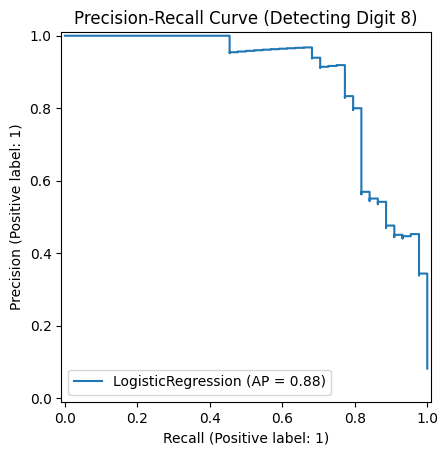

In [7]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegression

def show_pr_curve():
    # Binary classification for PR Curve
    X, y = load_digits(return_X_y=True)
    y = (y == 8).astype(int) # Is the digit an '8'?

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

    display = PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    display.ax_.set_title("Precision-Recall Curve (Detecting Digit 8)")
    plt.show()

show_pr_curve()

Visualization to show the PR curve(using lib)

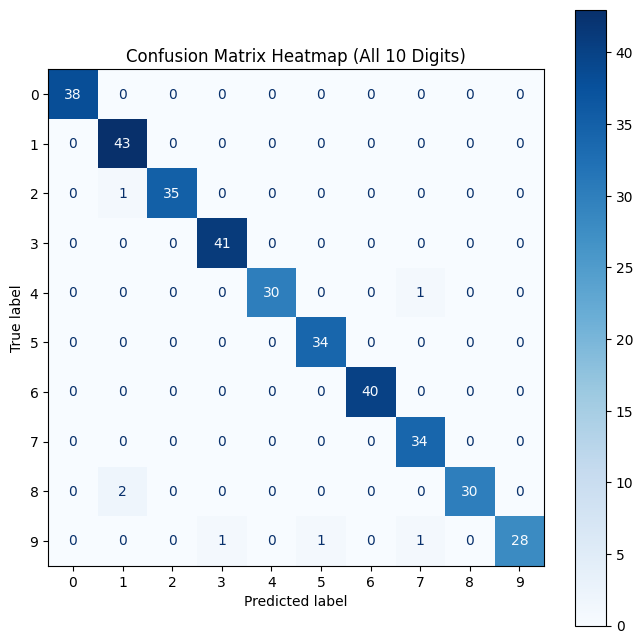

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def show_heatmap():
    X, y = load_digits(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = RandomForestClassifier().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix Heatmap (All 10 Digits)")
    plt.show()

show_heatmap()

Visualization to show the confusion Matrix(using lib)